In [152]:

import matplotlib.pyplot as plt

from sklearn.datasets import (make_classification, load_wine, load_iris, load_breast_cancer)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from sklearn.model_selection import cross_val_score

import pandas as pd
import numpy as np
import seaborn as sns

# Моє

Привести до купи:
- ~~як поведе себе гіт із файлом 4~~
- ~~як поведе себе гіт із папкою 5~~
- візуалізувати синтетичні
- почистити лишнє і відтворити синтетичні
- структурувати ірис бінарний
- структурувати ірис мультикласовий
- ліби почистити
- кросвалідацію на бінарний ірис
- чого бінарний ірис так просідає?
- дати норм візуаілізацію ірисам
- порефакторити

# Synthetic data

## Generate data

In [156]:
X_simple, y_simple = make_classification(
    n_samples=425,
    n_features=2,          
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,         
    flip_y=0.04,
    random_state=2026
)
X_simple[:5] 

array([[ 1.94734403, -0.94551972],
       [ 2.91324296,  3.55511465],
       [-0.45845376, -2.39981727],
       [ 1.97761416,  0.94672866],
       [-2.19010807, -1.2287111 ]])

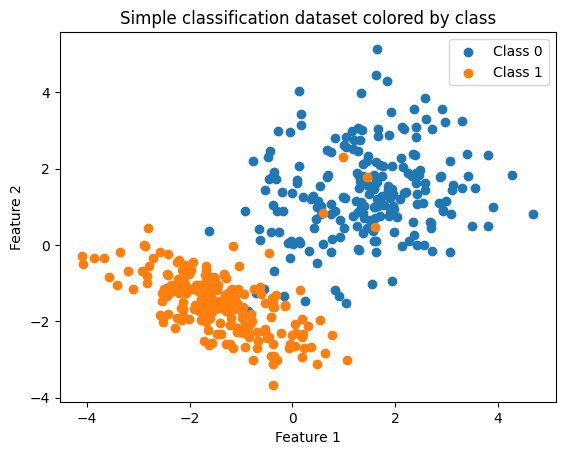

In [157]:
plt.figure()

for cls in (0,1):
    plt.scatter(
        X_simple[y_simple == cls, 0],
        X_simple[y_simple == cls, 1],
        label=f"Class {cls}"
    )
plt.title("Simple classification dataset colored by class")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

## Split data into train and test sets

In [158]:
X_train_simple, X_test_simple, y_train_simple, y_test_simple =  train_test_split(
    X_simple,
    y_simple,
    stratify=y_simple, 
    random_state=2026,
)

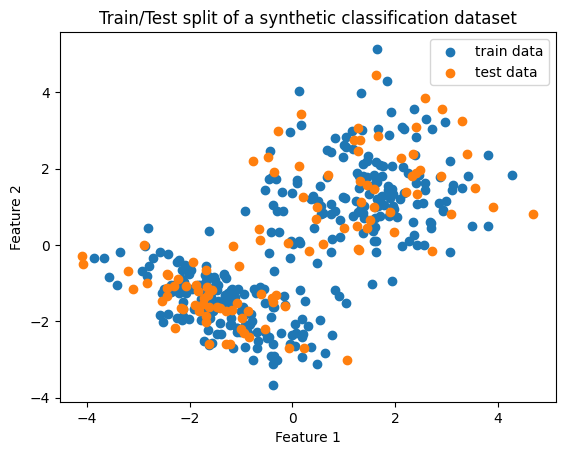

In [159]:
plt.figure()

for t, d in {'train': X_train_simple, 'test': X_test_simple}.items():
    plt.scatter(
        d[:, 0],
        d[:, 1],
        label=f"{t} data"
    )
plt.title("Train/Test split of a synthetic classification dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

## Check classes balance

In [160]:
pd.Series(y_simple).value_counts()

0    214
1    211
Name: count, dtype: int64

## Create and train the model

In [161]:
logreg = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=0.5, max_iter=2000)),
    ]
)

logreg.fit(X_train_simple, y_train_simple)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(C=0.5, max_iter=2000))])

## Make predictions and evaluate the model

In [162]:
pred = logreg.predict(X_test_simple)

metrics = {
    "accuracy": accuracy_score(y_test_simple, pred),
    "precision": precision_score(y_test_simple, pred, zero_division=0),
    "recall": recall_score(y_test_simple, pred, zero_division=0),
    "f1": f1_score(y_test_simple, pred, zero_division=0),
}

for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

accuracy: 0.9813
precision: 0.9636
recall: 1.0000
f1: 0.9815


## Реальні дані

### load data

In [30]:
breast = load_breast_cancer()
df_breast = pd.DataFrame(breast.data, columns=breast.feature_names)
df_breast['target'] = breast.target
df_breast.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [31]:
df_breast['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    df_breast.drop('target', axis=1),
    df_breast['target'],
    random_state=42
)

### iris

In [41]:
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [32]:
df_iris['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [61]:
df_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


#### binary classification

In [47]:
df_iris_2 = df_iris[df_iris['target'] != 0]
df_iris_2['target'].unique()

array([1, 2])

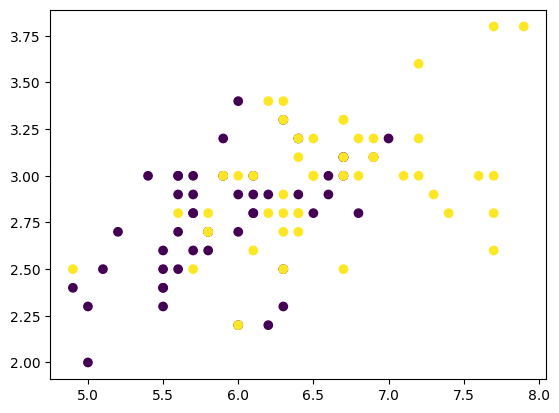

In [59]:
plt.scatter(df_iris_2['sepal length (cm)'], df_iris_2['sepal width (cm)'], c=df_iris_2['target'])

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    df_iris_2.drop('target', axis=1),
    df_iris_2['target'],
    
    random_state=42
)

In [ ]:
# logreg = Pipeline(
#     [
#         ("scaler", StandardScaler()),
#         ("model", LogisticRegression(C=1.0, max_iter=2000)),
#     ]
# )

In [140]:
logreg = Pipeline([
    # ("poly", PolynomialFeatures(degree=3)), # both commented lines returns same results
    # ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000))
])

In [141]:
logreg.fit(X_train, y_train)

Pipeline(steps=[('logreg', LogisticRegression(max_iter=2000))])

In [142]:
pred = logreg.predict(X_test)

In [143]:
print(f"accuracy: {accuracy_score(y_test, pred)}\nprecision: {precision_score(y_test, pred, zero_division=0)}\nrecall: {recall_score(y_test, pred, zero_division=0)}\nf1: {f1_score(y_test, pred, zero_division=0)}")

accuracy: 0.92
precision: 0.9285714285714286
recall: 0.9285714285714286
f1: 0.9285714285714286


#### multiclass clasification

In [144]:
X_train, X_test, y_train, y_test = train_test_split(
    df_iris.drop('target', axis=1),
    df_iris['target'],
    
    random_state=42
)

In [145]:
logreg = Pipeline([
    ('logreg', LogisticRegression(max_iter=2000))
])

In [146]:
logreg.fit(X_train, y_train)
pred = logreg.predict(X_test)

In [147]:
cm_iris = confusion_matrix(y_test, pred)

<Axes: >

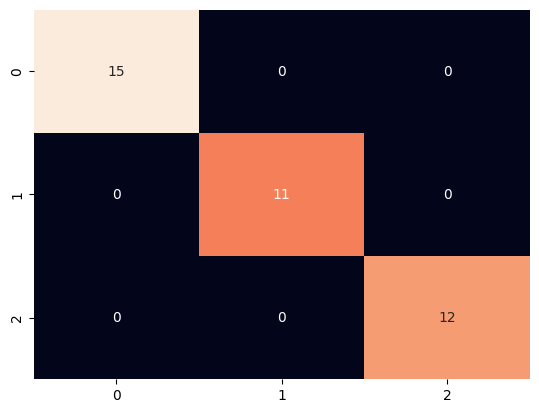

In [ ]:
sns.heatmap(
    cm_iris,
    annot=True,
    fmt="d",
    cbar=False)

In [151]:
accuracy_score(y_test, pred)

1.0

In [153]:
cross_val_score(logreg,  df_iris.drop('target', axis=1), df_iris['target'], cv=5)

array([0.96666667, 1.        , 0.93333333, 0.96666667, 1.        ])